# Feature Engineering

### Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

IN_DIR      = Path('../data/processed/keypoints_normalized')
IN_DIR_COMB = Path('../data/processed/keypoints_combined')

TIME_DICT = {
  '028': (9.90, 10.44, 11.20, 11.77),
  '030': (5.80, 6.12,  6.80,  7.63),
  '045': (6.54, 6.74,  7.36,  7.98),
  '047': (7.03, 7.36,  7.88,  8.80),
  '059': (6.65, 6.90,  8.10,  9.11),
  '061': (7.00, 7.40,  8.20,  9.00),
  '074': (6.07, 6.22,  6.80,  7.27),
  '076': (5.20, 5.80,  6.34,  7.20),
  '091': (6.39, 6.52,  7.14,  7.61),
  '093': (5.86, 6.22,  6.74,  7.50),
}

## Utgångsposition

In [3]:
def get_phase(df, t_start, t_end):
    return df[(df['time'] >= t_start) & (df['time'] <= t_end)].reset_index(drop=True)

def xy(df, joint):
    return df[[f'{joint}_x', f'{joint}_y']].values

def compute_angle(A, B, C, flip=False):
    BA = A - B
    BC = C - B
    dot   = (BA * BC).sum(axis=1)
    cross = BA[:, 0] * BC[:, 1] - BA[:, 1] * BC[:, 0]
    norm  = np.linalg.norm(BA, axis=1) * np.linalg.norm(BC, axis=1)
    angle = 180 - np.degrees(np.arccos(np.clip(dot / norm, -1, 1)))
    s = np.sign(cross)
    return (-s if flip else s) * angle

def trunk_angle(mid_shoulder, mid_hip):
    dx = mid_shoulder[:, 0] - mid_hip[:, 0]
    dy = mid_shoulder[:, 1] - mid_hip[:, 1]
    return -np.degrees(np.arctan2(dx, -dy))

In [4]:
def extract_utgångsposition(df):
    ls, rs = xy(df, 'left_shoulder'), xy(df, 'right_shoulder')
    lh, rh = xy(df, 'left_hip'),      xy(df, 'right_hip')
    lk, rk = xy(df, 'left_knee'),     xy(df, 'right_knee')
    la, ra = xy(df, 'left_ankle'),     xy(df, 'right_ankle')
    nose   = xy(df, 'nose')

    left_knee_a  = compute_angle(lh, lk, la)
    right_knee_a = compute_angle(rh, rk, ra)
    left_hip_a   = compute_angle(ls, lh, lk, flip=True)
    right_hip_a  = compute_angle(rs, rh, rk, flip=True)

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_a      = trunk_angle(mid_shoulder, mid_hip)
    head_trunk_a = compute_angle(mid_hip, mid_shoulder, nose)

    return {
        'utg_mean_left_knee_angle':  left_knee_a.mean(),
        'utg_mean_right_knee_angle': right_knee_a.mean(),
        'utg_delta_knee_angle':      np.abs(left_knee_a - right_knee_a).mean(),
        'utg_mean_left_hip_angle':   left_hip_a.mean(),
        'utg_mean_right_hip_angle':  right_hip_a.mean(),
        'utg_delta_hip_angle':       np.abs(left_hip_a - right_hip_a).mean(),
        'utg_mean_trunk_angle':      trunk_a.mean(),
        'utg_mean_head_trunk_angle': head_trunk_a.mean(),
        'utg_delta_hip_height':      np.abs(lh[:, 1] - rh[:, 1]).mean(),
    }

In [5]:
OUT_DIR = Path('../data/processed/features')
OUT_DIR.mkdir(parents=True, exist_ok=True)

rows = []
for vid_id, times in TIME_DICT.items():
    t0, t1 = times[0], times[1]
    df = pd.read_csv(next(IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    phase = get_phase(df, t0, t1)
    rows.append({'video': vid_id, **extract_utgångsposition(phase)})

df_utgång = pd.DataFrame(rows).set_index('video')
df_utgång.to_csv(OUT_DIR / 'utgångsposition.csv')
display(df_utgång.round(2))

,utg_mean_left_knee_angle,utg_mean_right_knee_angle,utg_delta_knee_angle,utg_mean_left_hip_angle,utg_mean_right_hip_angle,utg_delta_hip_angle,utg_mean_trunk_angle,utg_mean_head_trunk_angle,utg_delta_hip_height
video,,,,,,,,,
028,52.34,65.43,13.09,37.62,52.16,14.54,-8.41,22.40,0.06
030,52.90,61.51,8.61,40.55,51.51,10.95,-3.01,21.82,0.04
045,56.66,61.35,4.69,46.72,55.39,8.67,-5.69,22.40,0.03
047,52.82,56.87,4.04,45.74,55.72,9.99,0.48,19.32,0.03
059,60.89,60.51,0.93,44.22,44.79,0.85,-9.65,23.82,0.10
061,41.64,54.69,13.05,32.99,49.10,16.11,-0.28,19.06,0.06
074,64.83,65.37,0.58,42.28,49.69,7.41,-10.54,27.01,0.06
076,53.76,60.03,6.27,41.96,53.48,11.52,-0.55,19.87,0.06
091,52.52,65.34,12.82,36.48,50.61,14.13,-12.27,21.38,0.11


## Rörelseutförande

### Förberedelsefas

In [6]:
def extract_förberedelsefas(df_norm, df_comb):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')
    nose   = xy(df_norm, 'nose')
    lw, rw = xy(df_comb, 'left_wrist'),    xy(df_comb, 'right_wrist')

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_a      = trunk_angle(mid_shoulder, mid_hip)

    dt           = 1 / 50
    velocity     = np.diff(trunk_a) / dt
    acceleration = np.diff(velocity) / dt

    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_x   = ((lh_c + rh_c) / 2)[:, 0]

    head_trunk_a = compute_angle(mid_hip, mid_shoulder, nose)

    lw_acc = np.diff(np.diff(lw, axis=0) / dt, axis=0) / dt
    rw_acc = np.diff(np.diff(rw, axis=0) / dt, axis=0) / dt
    rms_wrist = (np.sqrt(np.mean(np.linalg.norm(lw_acc, axis=1) ** 2)) +
                 np.sqrt(np.mean(np.linalg.norm(rw_acc, axis=1) ** 2))) / 2

    return {
        'forb_initial_trunk_angle':         trunk_a[0],
        'forb_max_trunk_angle':             trunk_a.max(),
        'forb_delta_trunk_flexion':         trunk_a.max() - trunk_a[0],
        'forb_max_trunk_angular_velocity':  np.abs(velocity).max(),
        'forb_mean_trunk_angular_velocity': np.abs(velocity).mean(),
        'forb_trunk_hip_correlation':       np.corrcoef(trunk_a, mid_hip_x)[0, 1],
        'forb_rms_trunk_acceleration':      np.sqrt(np.mean(acceleration ** 2)),
        'forb_mean_head_trunk_angle':       head_trunk_a.mean(),
        'forb_rms_wrist_acceleration':      rms_wrist,
    }

### Uppresningsfas

In [7]:
def extract_uppresningsfas(df_norm, df_comb):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')
    lk, rk = xy(df_norm, 'left_knee'),     xy(df_norm, 'right_knee')
    la, ra = xy(df_norm, 'left_ankle'),     xy(df_norm, 'right_ankle')

    knee_a = (compute_angle(lh, lk, la) + compute_angle(rh, rk, ra)) / 2
    hip_a  = (compute_angle(ls, lh, lk, flip=True) + compute_angle(rs, rh, rk, flip=True)) / 2

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_a      = trunk_angle(mid_shoulder, mid_hip)

    dt        = 1 / 50
    knee_vel  = np.diff(knee_a) / dt
    trunk_vel = np.diff(trunk_a) / dt
    trunk_acc = np.diff(trunk_vel) / dt

    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_x   = ((lh_c + rh_c) / 2)[:, 0]
    hip_vel     = np.diff(mid_hip_x) / dt

    return {
        'uppr_initial_trunk_angle':          trunk_a[0],
        'uppr_total_knee_extension':         knee_a[0] - knee_a[-1],
        'uppr_peak_knee_extension_velocity': np.abs(knee_vel).max(),
        'uppr_total_hip_extension':          hip_a[0] - hip_a[-1],
        'uppr_trunk_reextension_angle':      trunk_a[0] - trunk_a[-1],
        'uppr_max_trunk_angular_velocity':   np.abs(trunk_vel).max(),
        'uppr_mean_trunk_angular_velocity':  np.abs(trunk_vel).mean(),
        'uppr_rms_trunk_acceleration':       np.sqrt(np.mean(trunk_acc ** 2)),
        'uppr_hip_forward_displacement':     mid_hip_x[0] - mid_hip_x[-1],
        'uppr_peak_hip_velocity':            np.abs(hip_vel).max(),
        'uppr_trunk_hip_correlation':        np.corrcoef(trunk_a, mid_hip_x)[0, 1],
    }

In [8]:
rows_forb, rows_uppr = [], []
for vid_id, times in TIME_DICT.items():
    t0, t1, t2, t3 = times
    df_norm = pd.read_csv(next(IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    df_comb = pd.read_csv(next(IN_DIR_COMB.glob(f'*_0{vid_id}_D.csv')))
    phase_forb_norm = get_phase(df_norm, t1, t2)
    phase_forb_comb = get_phase(df_comb, t1, t2)
    phase_uppr_norm = get_phase(df_norm, t2, t3)
    phase_uppr_comb = get_phase(df_comb, t2, t3)
    rows_forb.append({'video': vid_id,
                      **extract_förberedelsefas(phase_forb_norm, phase_forb_comb),
                      'forb_phase_duration': t2 - t1})
    rows_uppr.append({'video': vid_id,
                      **extract_uppresningsfas(phase_uppr_norm, phase_uppr_comb),
                      'uppr_phase_duration': t3 - t2})

df_forb = pd.DataFrame(rows_forb).set_index('video')
df_uppr = pd.DataFrame(rows_uppr).set_index('video')
df_forb.to_csv(OUT_DIR / 'förberedelsefas.csv')
df_uppr.to_csv(OUT_DIR / 'uppresningsfas.csv')
print("=== Förberedelsefas ==="); display(df_forb.round(4))
print("=== Uppresningsfas ===");  display(df_uppr.round(4))

=== Förberedelsefas ===


,forb_initial_trunk_angle,forb_max_trunk_angle,forb_delta_trunk_flexion,forb_max_trunk_angular_velocity,forb_mean_trunk_angular_velocity,forb_trunk_hip_correlation,forb_rms_trunk_acceleration,forb_mean_head_trunk_angle,forb_rms_wrist_acceleration,forb_phase_duration
video,,,,,,,,,,
028,-8.2543,17.9668,26.2211,81.7114,34.5015,-0.9501,1001.7944,23.6378,4.3536,0.76
030,-2.9200,18.9180,21.8379,77.9225,32.1146,-0.9521,434.1213,25.6834,4.6930,0.68
045,-5.6806,16.8473,22.5278,77.3474,36.4005,-0.9377,693.5571,27.3379,2.2741,0.62
047,0.3241,19.3051,18.9810,71.6533,36.5019,-0.3730,453.4612,18.5213,4.2392,0.52
059,-9.6546,23.5612,33.2159,89.5574,27.7810,-0.7697,918.9324,28.9747,4.4685,1.20
061,-0.1756,17.7246,17.9002,55.6288,22.6289,-0.7547,480.9570,16.9888,3.8836,0.80
074,-10.5066,10.0193,20.5259,67.7181,36.1207,-0.7545,556.6115,20.0470,5.6889,0.58
076,-0.4571,18.3626,18.8197,92.1273,34.8513,-0.9419,597.9629,18.3282,1.8875,0.54
091,-12.2442,11.8381,24.0823,91.4901,38.8425,-0.9728,1282.3136,28.0199,2.7952,0.62


=== Uppresningsfas ===


,uppr_initial_trunk_angle,uppr_total_knee_extension,uppr_peak_knee_extension_velocity,uppr_total_hip_extension,uppr_trunk_reextension_angle,uppr_max_trunk_angular_velocity,uppr_mean_trunk_angular_velocity,uppr_rms_trunk_acceleration,uppr_hip_forward_displacement,uppr_peak_hip_velocity,uppr_trunk_hip_correlation,uppr_phase_duration
video,,,,,,,,,,,,
028,17.9668,39.2046,149.7589,53.0275,16.7313,76.4184,43.4012,1494.4534,0.0339,0.1832,0.9897,0.57
030,18.9180,45.5370,108.8946,59.1321,18.8224,75.3757,38.8928,785.9082,0.0390,0.1195,0.9896,0.83
045,16.8473,37.4584,181.4964,46.5385,9.5224,80.5183,34.5289,860.4025,0.0269,0.0997,0.9717,0.62
047,19.3051,42.1999,110.0240,58.6282,18.9048,74.9381,30.4622,715.0685,0.0430,0.1261,0.9938,0.92
059,23.5612,41.8517,90.3646,62.0965,21.9782,99.5038,34.9617,738.9326,0.0444,0.1089,0.9905,1.01
061,17.7246,27.9785,69.0931,41.7660,15.7799,46.5803,22.6877,453.3361,0.0372,0.1116,0.9982,0.80
074,9.5953,54.6582,196.6992,54.4878,7.0893,56.1835,24.3668,902.8328,0.0298,0.1260,0.9478,0.47
076,18.3626,42.8140,113.5752,58.8522,19.7539,70.9583,30.2404,782.2688,0.0452,0.1842,0.9959,0.86
091,11.8381,44.4236,175.6234,48.2712,7.6680,55.3543,28.9921,939.5055,0.0315,0.1352,0.9665,0.47


## Plots

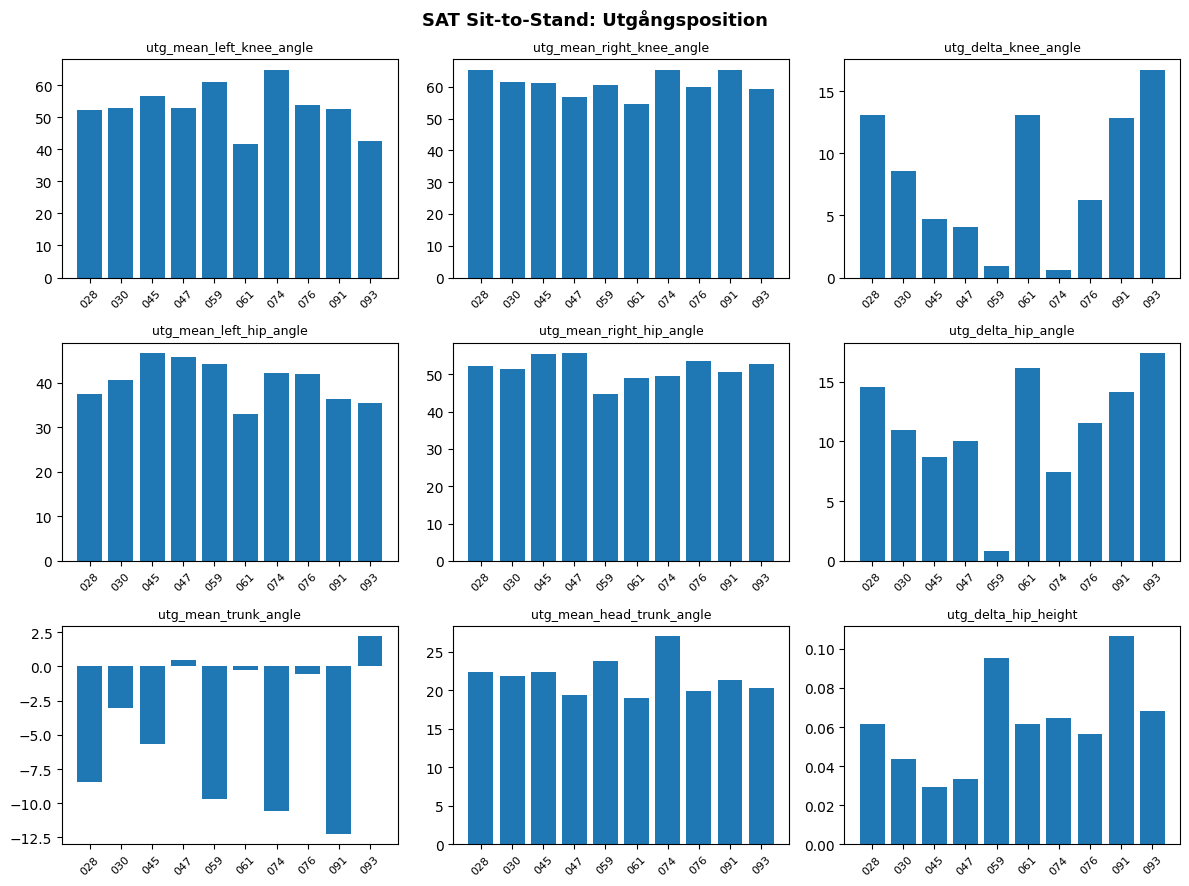

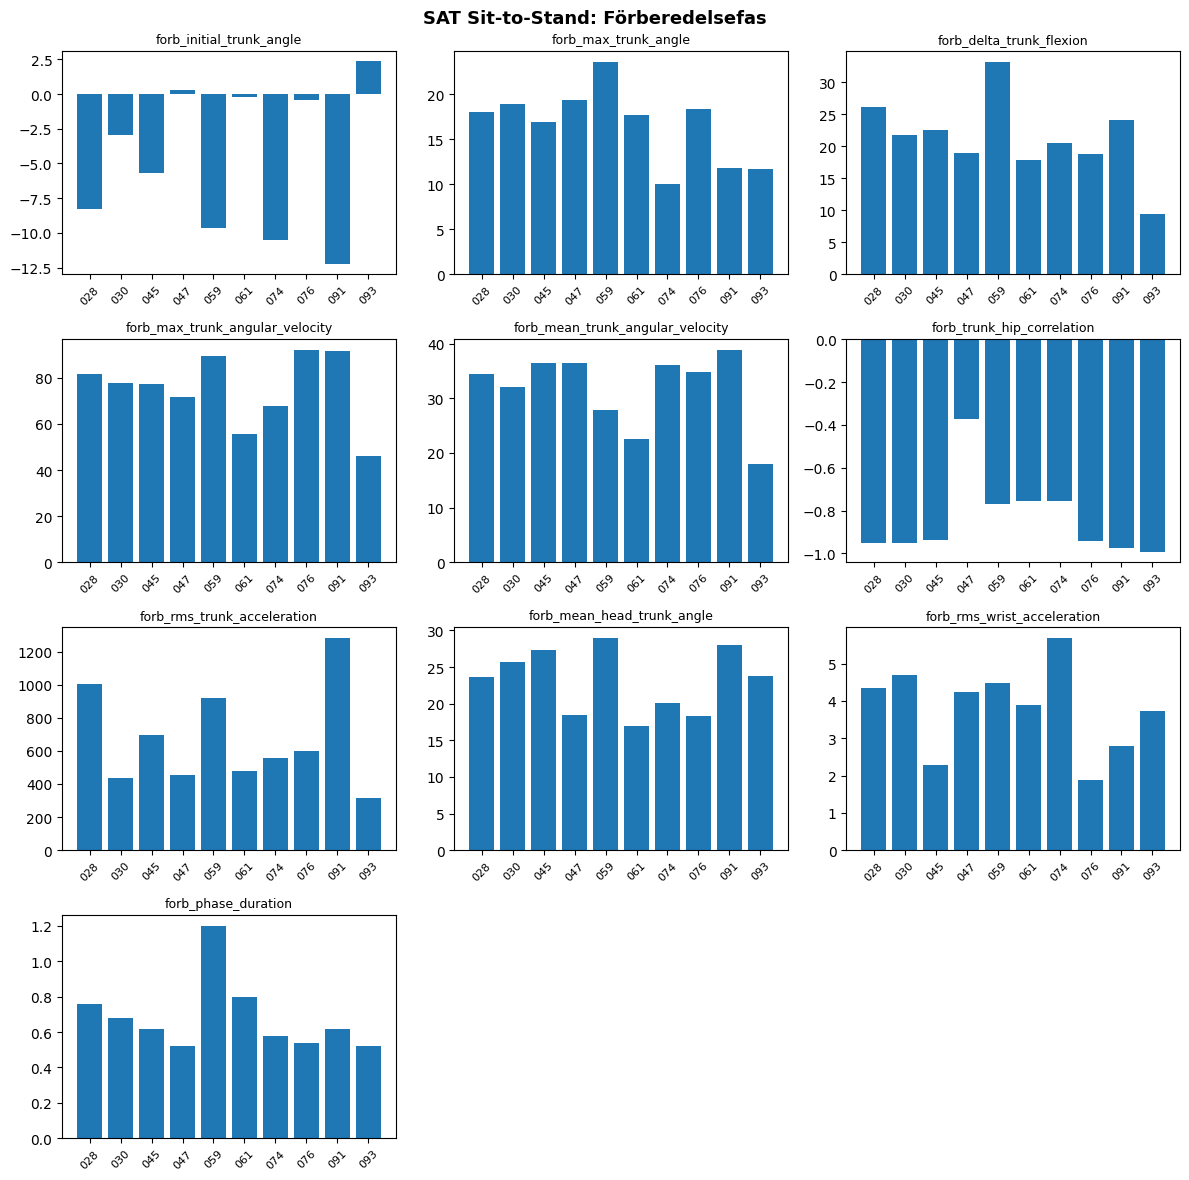

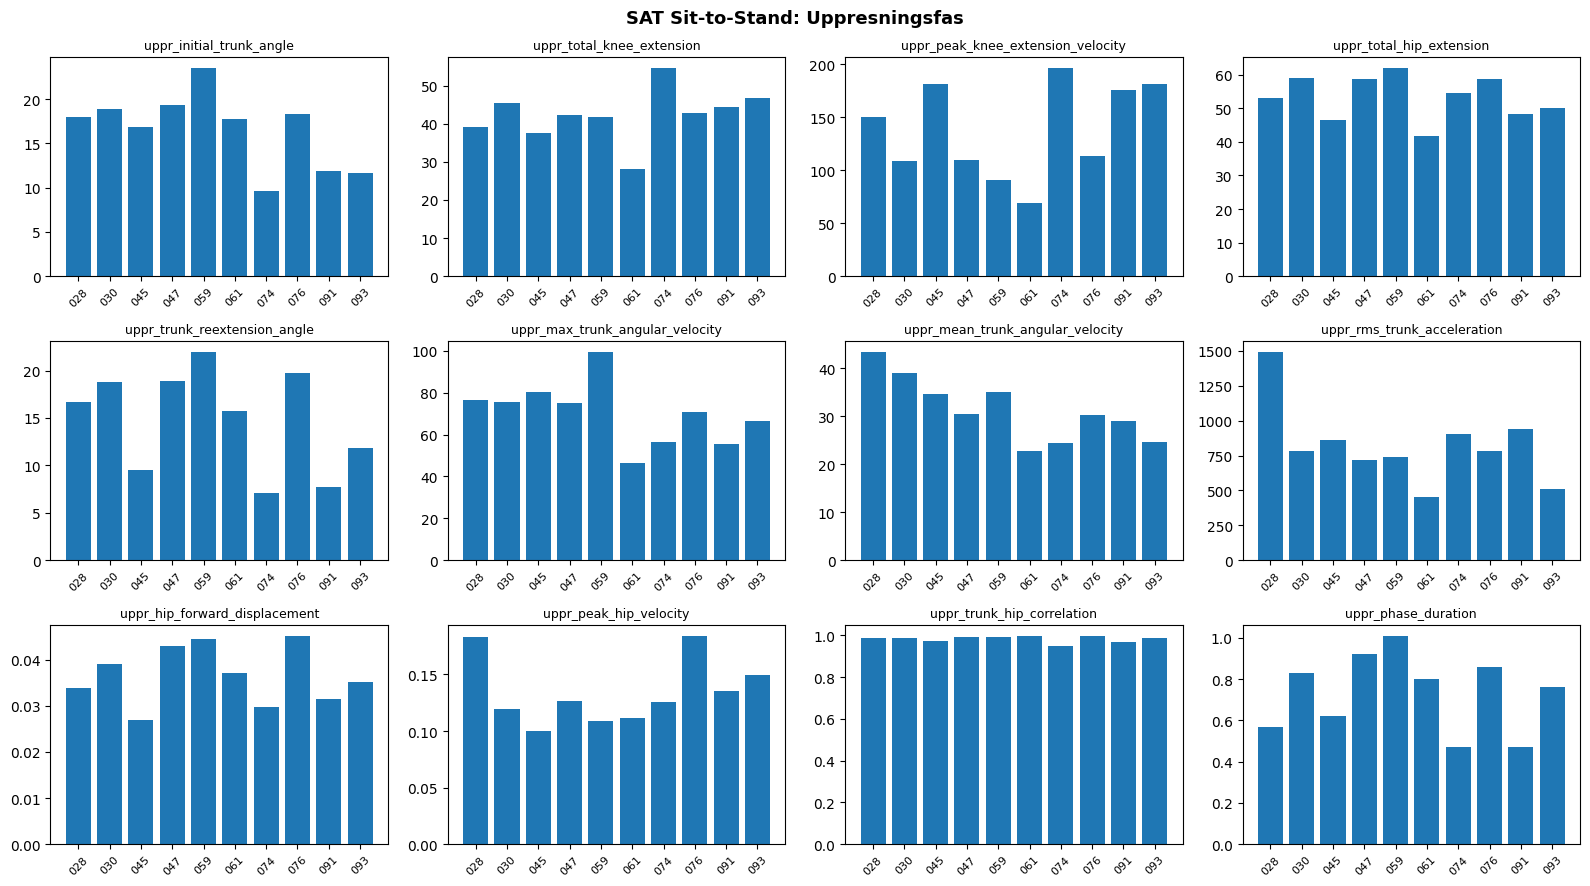

In [9]:
def plot_phase(df, title, ncols, filepath):
    features = df.columns.tolist()
    nrows = (len(features) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()
    for i, feat in enumerate(features):
        axes[i].bar(df.index, df[feat])
        axes[i].set_title(feat, fontsize=9)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(filepath, dpi=150)
    plt.show()

plot_phase(df_utgång, 'SAT Sit-to-Stand: Utgångsposition', ncols=3, filepath=OUT_DIR / 'utgångsposition.png')
plot_phase(df_forb,   'SAT Sit-to-Stand: Förberedelsefas', ncols=3, filepath=OUT_DIR / 'förberedelsefas.png')
plot_phase(df_uppr,   'SAT Sit-to-Stand: Uppresningsfas',  ncols=4, filepath=OUT_DIR / 'uppresningsfas.png')

## MoLab Features

In [10]:
from pathlib import Path
import pandas as pd

MOLAB_FULL_DIR    = Path('../data/processed/molab')
MOLAB_CROPPED_DIR = Path('../data/processed/molab_cropped')

JOINT_ANGLE_COLS = [c for c in pd.read_csv(MOLAB_CROPPED_DIR / '0028_molab.csv', nrows=0).columns
                    if c.startswith('JointAngle/')]

offsets = {}
for vid in TIME_DICT:
    full = pd.read_csv(MOLAB_FULL_DIR / f'0{vid}_molab.csv')
    pre  = full[full['molab_frame'] < 41]
    offsets[vid] = pre[JOINT_ANGLE_COLS].mean()

display_cols = ['JointAngle/L_knee_X', 'JointAngle/R_knee_X',
                'JointAngle/L_hip_X',  'JointAngle/R_hip_X',
                'JointAngle/pelvis_X', 'JointAngle/pelvis_Y']
offset_df = pd.DataFrame(offsets).T[display_cols].round(1)
offset_df.columns = ['L_knee', 'R_knee', 'L_hip', 'R_hip', 'pelvis_X', 'pelvis_Y']
print("Pre-calibration offsets (absolute joint angles while seated, degrees):")
display(offset_df)

molab_corrected = {}
for vid in TIME_DICT:
    cropped = pd.read_csv(MOLAB_CROPPED_DIR / f'0{vid}_molab.csv')
    corrected = cropped.copy()
    corrected[JOINT_ANGLE_COLS] = cropped[JOINT_ANGLE_COLS] + offsets[vid]
    molab_corrected[vid] = corrected

print(f"\nmolab_corrected: dict with {len(molab_corrected)} videos, ready for feature engineering.")
print("Non-JointAngle columns (gyro, acc) are unchanged.")

Pre-calibration offsets (absolute joint angles while seated, degrees):


,L_knee,R_knee,L_hip,R_hip,pelvis_X,pelvis_Y
028,92.9,95.9,46.3,50.9,-25.6,-0.3
030,98.2,101.7,83.5,89.4,11.8,-3.0
045,82.5,80.2,55.0,57.4,-11.7,-4.9
047,90.4,89.5,95.1,100.7,28.2,0.0
059,95.5,86.3,46.3,46.0,-21.4,-2.7
061,96.8,90.3,76.6,76.2,9.6,-3.3
074,104.8,97.9,71.5,71.2,-2.4,1.4
076,104.8,99.3,99.9,100.0,26.1,1.4
091,83.1,81.0,37.9,43.1,-29.1,-0.4
093,91.7,91.9,97.0,102.7,33.6,-1.1



molab_corrected: dict with 10 videos, ready for feature engineering.
Non-JointAngle columns (gyro, acc) are unchanged.


In [11]:
import numpy as np

def molab_phase(df, t_start, t_end):
    return df[(df['video_time'] >= t_start) & (df['video_time'] <= t_end)]

def rms(x):
    return np.sqrt(np.mean(x ** 2))

def molab_extract_utgångsposition(df, t0, t1):
    p = molab_phase(df, t0, t1)
    lk = p['JointAngle/L_knee_X']
    rk = p['JointAngle/R_knee_X']
    return {
        'utg_mean_L_knee_flexion':  lk.mean(),
        'utg_mean_R_knee_flexion':  rk.mean(),
        'utg_delta_knee_asymmetry': abs(lk.mean() - rk.mean()),
        'utg_mean_L_hip_flexion':   p['JointAngle/L_hip_X'].mean(),
        'utg_mean_R_hip_flexion':   p['JointAngle/R_hip_X'].mean(),
        'utg_mean_pelvis_tilt':     p['JointAngle/pelvis_X'].mean(),
        'utg_mean_pelvis_lateral':  p['JointAngle/pelvis_Y'].abs().mean(),
    }

def molab_extract_rörelseutförande(df, t1, t2, t3):
    forb = molab_phase(df, t1, t2)
    uppr = molab_phase(df, t2, t3)
    lk_up, rk_up = uppr['JointAngle/L_knee_X'], uppr['JointAngle/R_knee_X']
    return {
        'forb_initial_pelvis_tilt':  forb['JointAngle/pelvis_X'].iloc[0],
        'forb_max_pelvis_tilt':      forb['JointAngle/pelvis_X'].max(),
        'forb_delta_pelvis_tilt':    forb['JointAngle/pelvis_X'].max() - forb['JointAngle/pelvis_X'].min(),
        'forb_peak_pelvis_gyro':     forb['SegmentGyro/pelvis_X'].abs().max(),
        'forb_mean_pelvis_gyro':     forb['SegmentGyro/pelvis_X'].abs().mean(),
        'forb_rms_pelvis_acc':       rms(forb['SegmentAcc/pelvis_Y'].values),
        'forb_hip_flexion_range':    ((forb['JointAngle/L_hip_X'].max() - forb['JointAngle/L_hip_X'].min()) +
                                      (forb['JointAngle/R_hip_X'].max() - forb['JointAngle/R_hip_X'].min())) / 2,
        'uppr_initial_pelvis_tilt':  uppr['JointAngle/pelvis_X'].iloc[0],
        'uppr_delta_pelvis_tilt':    uppr['JointAngle/pelvis_X'].max() - uppr['JointAngle/pelvis_X'].min(),
        'uppr_peak_pelvis_gyro':     uppr['SegmentGyro/pelvis_X'].abs().max(),
        'uppr_mean_pelvis_gyro':     uppr['SegmentGyro/pelvis_X'].abs().mean(),
        'uppr_rms_pelvis_acc':       rms(uppr['SegmentAcc/pelvis_Y'].values),
        'uppr_total_knee_extension': ((lk_up.max() - lk_up.min()) + (rk_up.max() - rk_up.min())) / 2,
        'uppr_peak_shank_gyro':      max(uppr['SegmentGyro/L_shank_X'].abs().max(),
                                         uppr['SegmentGyro/R_shank_X'].abs().max()),
        'uppr_total_hip_extension':  ((uppr['JointAngle/L_hip_X'].max() - uppr['JointAngle/L_hip_X'].min()) +
                                      (uppr['JointAngle/R_hip_X'].max() - uppr['JointAngle/R_hip_X'].min())) / 2,
    }

In [12]:
rows_utg, rows_forb, rows_uppr = [], [], []

for vid, (t0, t1, t2, t3) in TIME_DICT.items():
    df = molab_corrected[vid]
    rows_utg.append({'video': vid, **molab_extract_utgångsposition(df, t0, t1)})
    all_ru = molab_extract_rörelseutförande(df, t1, t2, t3)
    rows_forb.append({'video': vid, **{k: v for k, v in all_ru.items() if k.startswith('forb_')}})
    rows_uppr.append({'video': vid, **{k: v for k, v in all_ru.items() if k.startswith('uppr_')}})

OUT_DIR = Path('../data/processed/features')

df_molab_utg  = pd.DataFrame(rows_utg).set_index('video')
df_molab_forb = pd.DataFrame(rows_forb).set_index('video')
df_molab_uppr = pd.DataFrame(rows_uppr).set_index('video')

df_molab_utg.to_csv(OUT_DIR  / 'molab_utgångsposition.csv')
df_molab_forb.to_csv(OUT_DIR / 'molab_förberedelsefas.csv')
df_molab_uppr.to_csv(OUT_DIR / 'molab_uppresningsfas.csv')

print("=== Utgångsposition ===");  display(df_molab_utg.round(2))
print("=== Förberedelsefas ===");  display(df_molab_forb.round(2))
print("=== Uppresningsfas ===");   display(df_molab_uppr.round(2))

=== Utgångsposition ===


,utg_mean_L_knee_flexion,utg_mean_R_knee_flexion,utg_delta_knee_asymmetry,utg_mean_L_hip_flexion,utg_mean_R_hip_flexion,utg_mean_pelvis_tilt,utg_mean_pelvis_lateral
video,,,,,,,
028,92.87,95.95,3.08,46.36,50.95,-25.63,0.35
030,98.38,101.87,3.49,83.71,89.66,11.88,2.85
045,82.47,80.17,2.30,55.09,57.45,-11.58,4.83
047,90.55,89.59,0.96,95.18,100.90,28.48,0.06
059,95.52,86.24,9.28,45.83,45.41,-21.77,2.49
061,98.95,92.27,6.68,78.76,78.01,9.37,3.43
074,105.08,97.87,7.21,71.52,71.01,-2.64,1.51
076,104.90,99.44,5.46,100.11,100.33,26.31,1.36
091,82.77,81.03,1.74,37.82,43.10,-28.90,0.34


=== Förberedelsefas ===


,forb_initial_pelvis_tilt,forb_max_pelvis_tilt,forb_delta_pelvis_tilt,forb_peak_pelvis_gyro,forb_mean_pelvis_gyro,forb_rms_pelvis_acc,forb_hip_flexion_range
video,,,,,,,
028,-25.41,30.45,55.86,234.17,86.42,0.48,47.51
030,11.67,44.96,33.77,127.97,50.48,0.25,27.84
045,-11.43,44.80,56.24,283.58,89.50,0.44,49.53
047,29.13,60.14,31.00,130.84,59.55,0.29,19.25
059,-21.74,33.00,55.61,137.80,47.33,0.34,45.51
061,9.52,37.03,27.51,79.80,35.11,0.20,16.73
074,-2.30,38.70,44.12,406.10,86.02,0.36,32.29
076,27.04,54.23,27.20,96.18,51.28,0.24,15.79
091,-28.98,42.00,73.26,256.18,120.67,0.56,68.03


=== Uppresningsfas ===


,uppr_initial_pelvis_tilt,uppr_delta_pelvis_tilt,uppr_peak_pelvis_gyro,uppr_mean_pelvis_gyro,uppr_rms_pelvis_acc,uppr_total_knee_extension,uppr_peak_shank_gyro,uppr_total_hip_extension
video,,,,,,,,
028,29.86,26.47,85.66,52.36,0.74,82.36,39.43,96.05
030,43.71,42.05,125.47,63.37,0.51,94.81,34.06,117.97
045,43.84,24.29,97.13,54.10,0.85,65.69,38.37,77.08
047,59.38,42.88,110.64,52.46,0.38,87.10,38.88,115.70
059,32.42,6.07,78.02,16.36,0.84,86.50,35.10,79.53
061,36.32,13.95,72.15,28.13,0.49,75.59,31.95,73.71
074,38.28,10.81,77.27,27.88,0.64,86.73,109.41,77.81
076,53.78,34.09,82.65,43.93,0.34,88.20,45.48,109.92
091,41.29,29.00,134.68,73.93,0.90,80.36,89.88,96.07


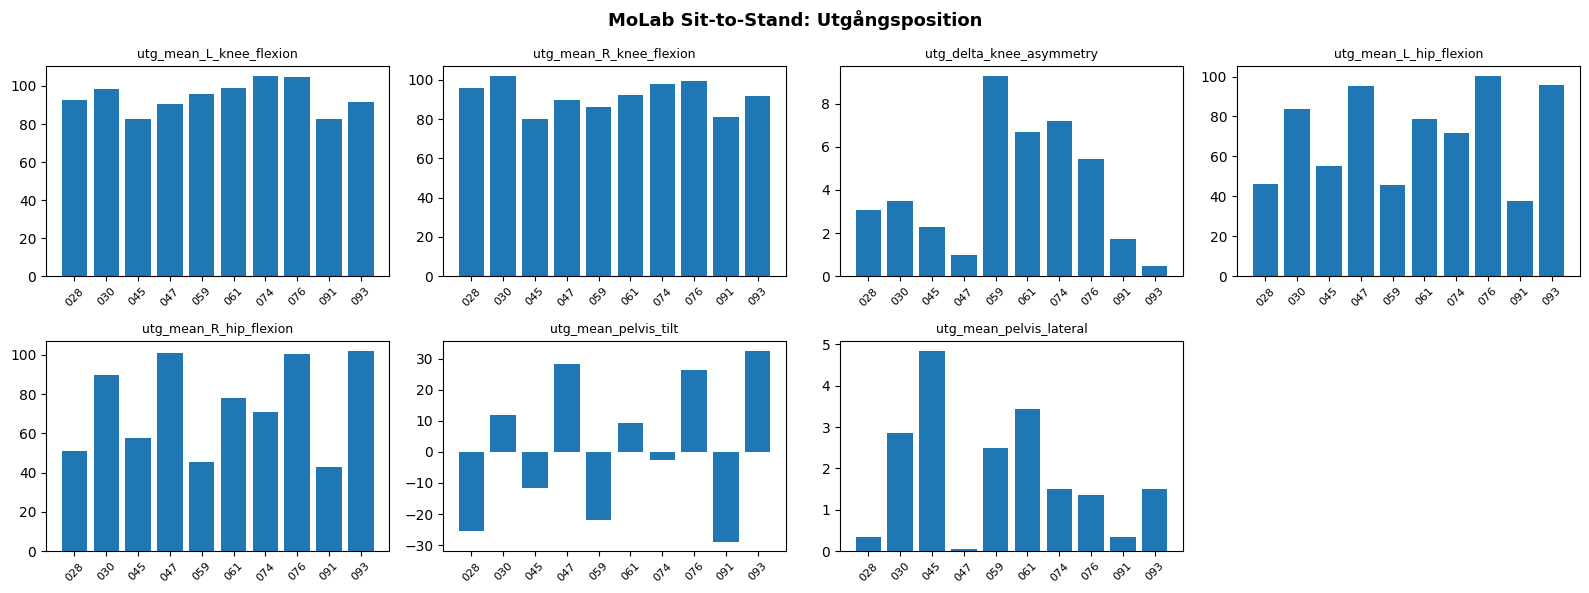

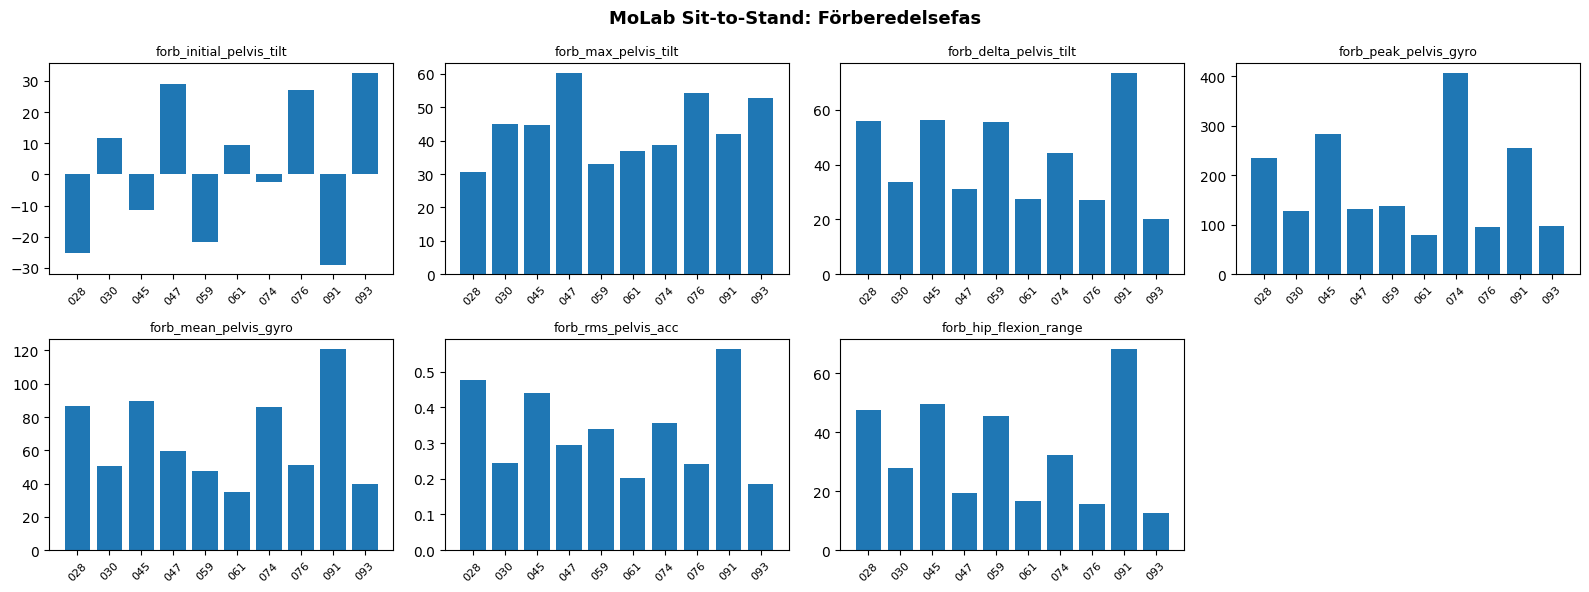

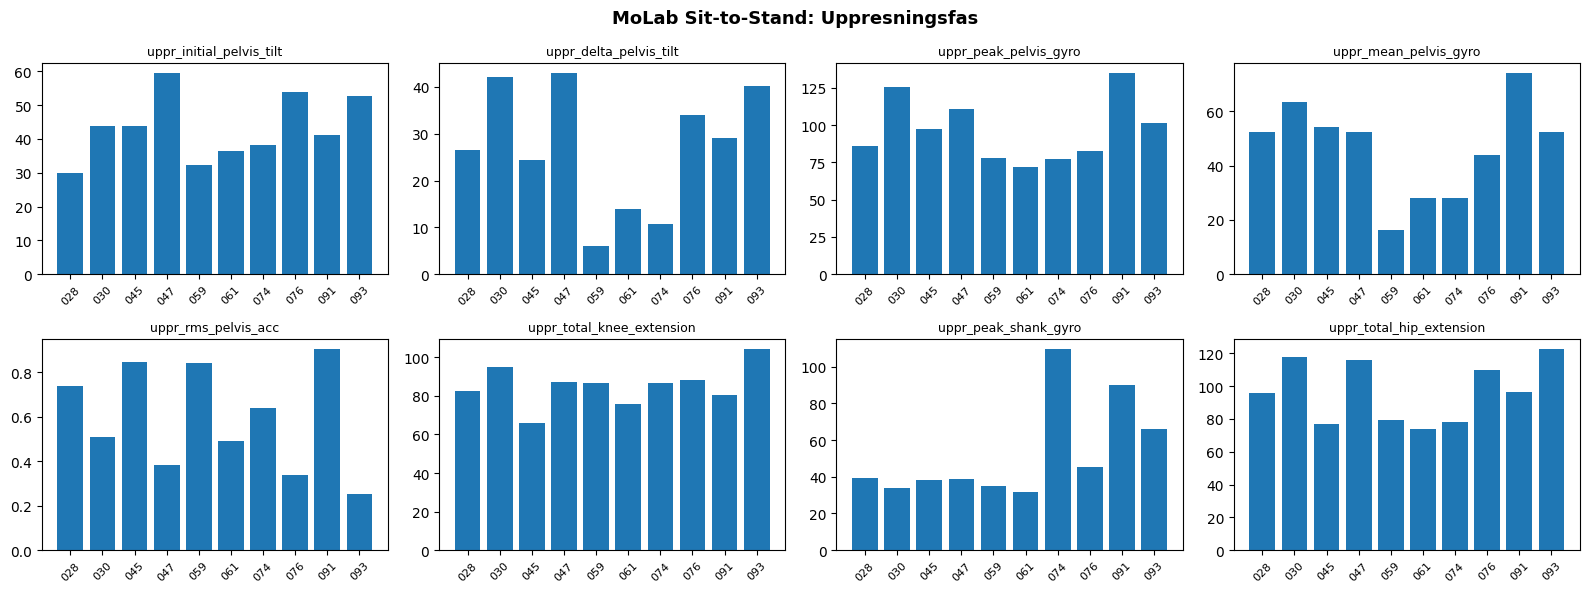

In [13]:
plot_phase(df_molab_utg,  'MoLab Sit-to-Stand: Utgångsposition', ncols=4, filepath=OUT_DIR / 'molab_utgångsposition.png')
plot_phase(df_molab_forb, 'MoLab Sit-to-Stand: Förberedelsefas', ncols=4, filepath=OUT_DIR / 'molab_förberedelsefas.png')
plot_phase(df_molab_uppr, 'MoLab Sit-to-Stand: Uppresningsfas',  ncols=4, filepath=OUT_DIR / 'molab_uppresningsfas.png')

# Stand to sit

In [14]:
DOWN_TIME_DICT = {
  '028': (11.87, 11.90, 12.57, 12.82),
  '030': (8.07, 9.70, 10.64, 11.16),
  '045': (7.94, 7.96, 8.74, 9.26),
  '047': (9.20, 10.14, 11.10, 11.70),
  '059': (9.11, 9.18, 10.37, 11.06),
  '061': (10.57, 10.88, 12.26, 13.00),
  '074': (7.27, 7.30, 7.88, 8.14),
  '076': (8.27, 8.72, 9.73, 10.32),
  '091': (7.56, 7.58, 8.09, 8.18),
  '093': (8.50, 9.24, 10.08, 10.74),
}

In [15]:
DOWN_IN_DIR      = Path('../data/processed/keypoints_normalized_down')
DOWN_IN_DIR_COMB = Path('../data/processed/keypoints_combined_down')
DOWN_OUT_DIR     = Path('../data/processed/features_down')
DOWN_OUT_DIR.mkdir(parents=True, exist_ok=True)

### Utgångsposition

In [16]:
def extract_utgångsposition_down(df):
    ls, rs = xy(df, 'left_shoulder'), xy(df, 'right_shoulder')
    lh, rh = xy(df, 'left_hip'),      xy(df, 'right_hip')
    lk, rk = xy(df, 'left_knee'),     xy(df, 'right_knee')
    la, ra = xy(df, 'left_ankle'),     xy(df, 'right_ankle')
    nose   = xy(df, 'nose')

    left_knee_a  = compute_angle(lh, lk, la)
    right_knee_a = compute_angle(rh, rk, ra)
    left_hip_a   = compute_angle(ls, lh, lk, flip=True)
    right_hip_a  = compute_angle(rs, rh, rk, flip=True)

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_a      = trunk_angle(mid_shoulder, mid_hip)
    head_trunk_a = compute_angle(mid_hip, mid_shoulder, nose)

    stance_w = np.linalg.norm(la - ra, axis=1)
    hip_w    = np.linalg.norm(lh - rh, axis=1)
    knee_fwd = ((la[:, 0] - lk[:, 0]) + (ra[:, 0] - rk[:, 0])) / 2

    return {
        'utg_stance_width':          stance_w.mean(),
        'utg_stance_to_hip_ratio':   (stance_w / np.clip(hip_w, 1e-6, None)).mean(),
        'utg_mean_left_knee_angle':  left_knee_a.mean(),
        'utg_mean_right_knee_angle': right_knee_a.mean(),
        'utg_delta_knee_angle':      np.abs(left_knee_a - right_knee_a).mean(),
        'utg_mean_left_hip_angle':   left_hip_a.mean(),
        'utg_mean_right_hip_angle':  right_hip_a.mean(),
        'utg_delta_hip_angle':       np.abs(left_hip_a - right_hip_a).mean(),
        'utg_mean_trunk_angle':      trunk_a.mean(),
        'utg_mean_head_trunk_angle': head_trunk_a.mean(),
        'utg_shoulder_asym':         np.abs(ls[:, 1] - rs[:, 1]).mean(),
        'utg_hip_asym':              np.abs(lh[:, 1] - rh[:, 1]).mean(),
        'utg_knee_asym':             np.abs(lk[:, 1] - rk[:, 1]).mean(),
        'utg_mean_knee_forward':     knee_fwd.mean(),
    }

In [17]:
rows = []
for vid_id, times in DOWN_TIME_DICT.items():
    t0, t1 = times[0], times[1]
    df = pd.read_csv(next(DOWN_IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    phase = get_phase(df, t0, t1)
    rows.append({'video': vid_id, **extract_utgångsposition_down(phase)})

df_down_utgång = pd.DataFrame(rows).set_index('video')
df_down_utgång.to_csv(DOWN_OUT_DIR / 'down_utgångsposition.csv')
display(df_down_utgång.round(2))

,utg_stance_width,utg_stance_to_hip_ratio,utg_mean_left_knee_angle,utg_mean_right_knee_angle,utg_delta_knee_angle,utg_mean_left_hip_angle,utg_mean_right_hip_angle,utg_delta_hip_angle,utg_mean_trunk_angle,utg_mean_head_trunk_angle,utg_shoulder_asym,utg_hip_asym,utg_knee_asym,utg_mean_knee_forward
video,,,,,,,,,,,,,,
028,0.14,1.18,2.44,7.82,5.38,0.28,4.10,3.82,0.61,17.78,0.01,0.01,0.04,0.05
030,0.14,0.92,0.92,0.34,0.60,-2.39,-0.88,1.51,0.62,18.52,0.05,0.01,0.02,0.04
045,0.14,0.91,10.28,6.75,3.53,15.23,13.53,1.70,7.42,16.27,0.01,0.01,0.00,0.02
047,0.15,1.03,3.91,1.29,2.62,-1.28,-0.22,1.06,0.25,17.74,0.01,0.01,0.02,0.04
059,0.11,0.81,2.58,6.06,3.47,-0.16,0.60,0.76,1.33,17.17,0.02,0.00,0.05,0.06
061,0.12,0.72,4.29,5.66,1.38,-2.32,0.47,2.80,-0.42,15.44,0.05,0.01,0.04,0.06
074,0.17,1.30,5.72,5.46,0.58,4.71,6.54,1.84,2.03,11.89,0.02,0.00,0.05,0.03
076,0.11,0.67,1.84,-1.31,3.15,-3.85,-5.90,2.05,-1.58,19.34,0.04,0.01,0.03,0.04
091,0.16,1.12,4.44,2.37,2.07,7.52,9.38,1.87,4.54,17.50,0.01,0.01,0.03,-0.01


### Rörelseutförande

#### Fas 1 (Inledande nedgående rörelse)

In [18]:
def extract_ned_down(df_norm, df_comb):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')
    lk, rk = xy(df_norm, 'left_knee'),     xy(df_norm, 'right_knee')
    la, ra = xy(df_norm, 'left_ankle'),     xy(df_norm, 'right_ankle')

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_a      = trunk_angle(mid_shoulder, mid_hip)

    left_knee_a  = compute_angle(lh, lk, la)
    right_knee_a = compute_angle(rh, rk, ra)
    left_hip_a   = compute_angle(ls, lh, lk, flip=True)
    right_hip_a  = compute_angle(rs, rh, rk, flip=True)

    knee_fwd = ((la[:, 0] - lk[:, 0]) + (ra[:, 0] - rk[:, 0])) / 2

    dt           = 1 / 50
    velocity     = np.diff(trunk_a) / dt
    acceleration = np.diff(velocity) / dt

    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_c   = (lh_c + rh_c) / 2
    hip_vel_y   = np.diff(mid_hip_c[:, 1]) / dt
    hip_acc_y   = np.diff(hip_vel_y) / dt

    return {
        'ned_initial_trunk_angle':          trunk_a[0],
        'ned_max_trunk_angle':              trunk_a.max(),
        'ned_delta_trunk_angle':            trunk_a[-1] - trunk_a[0],
        'ned_ROM_trunk':                    trunk_a.max() - trunk_a.min(),
        'ned_peak_trunk_angular_velocity':  np.abs(velocity).max(),
        'ned_mean_trunk_angular_velocity':  np.abs(velocity).mean(),
        'ned_rms_trunk_acceleration':       np.sqrt(np.mean(acceleration ** 2)),
        'ned_ROM_hip':                      ((left_hip_a.max() - left_hip_a.min()) +
                                              (right_hip_a.max() - right_hip_a.min())) / 2,
        'ned_ROM_knee':                     ((left_knee_a.max() - left_knee_a.min()) +
                                              (right_knee_a.max() - right_knee_a.min())) / 2,
        'ned_mean_knee_forward':            knee_fwd.mean(),
        'ned_delta_knee_forward':           knee_fwd[-1] - knee_fwd[0],
        'ned_knee_asym':                    np.abs(lk[:, 1] - rk[:, 1]).mean(),
        'ned_hip_descent':                  mid_hip_c[-1, 1] - mid_hip_c[0, 1],
        'ned_hip_backward_displacement':    mid_hip_c[-1, 0] - mid_hip_c[0, 0],
        'ned_trunk_hip_correlation':        np.corrcoef(trunk_a, mid_hip_c[:, 1])[0, 1],
        'ned_rms_pelvis_acc_y':             np.sqrt(np.mean(hip_acc_y ** 2)),
        'ned_peak_pelvis_velocity_y':       np.abs(hip_vel_y).max(),
    }

#### Fas 2 (Avslutande bakåtgående rörelse)

In [19]:
def extract_bak_down(df_norm, df_comb):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')
    lk, rk = xy(df_norm, 'left_knee'),     xy(df_norm, 'right_knee')
    la, ra = xy(df_norm, 'left_ankle'),     xy(df_norm, 'right_ankle')
    lw, rw = xy(df_comb, 'left_wrist'),    xy(df_comb, 'right_wrist')

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_a      = trunk_angle(mid_shoulder, mid_hip)

    left_knee_a  = compute_angle(lh, lk, la)
    right_knee_a = compute_angle(rh, rk, ra)
    left_hip_a   = compute_angle(ls, lh, lk, flip=True)
    right_hip_a  = compute_angle(rs, rh, rk, flip=True)

    dt           = 1 / 50
    velocity     = np.diff(trunk_a) / dt
    acceleration = np.diff(velocity) / dt

    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_c   = (lh_c + rh_c) / 2
    hip_x, hip_y = mid_hip_c[:, 0], mid_hip_c[:, 1]

    hip_acc_x = np.diff(np.diff(hip_x) / dt) / dt
    hip_acc_y = np.diff(np.diff(hip_y) / dt) / dt

    lw_acc = np.diff(np.diff(lw, axis=0) / dt, axis=0) / dt
    rw_acc = np.diff(np.diff(rw, axis=0) / dt, axis=0) / dt
    rms_wrist = (np.sqrt(np.mean(np.linalg.norm(lw_acc, axis=1) ** 2)) +
                 np.sqrt(np.mean(np.linalg.norm(rw_acc, axis=1) ** 2))) / 2

    return {
        'bak_initial_trunk_angle':          trunk_a[0],
        'bak_delta_trunk_flexion':          trunk_a[0] - trunk_a[-1],
        'bak_peak_trunk_angular_velocity':  np.abs(velocity).max(),
        'bak_mean_trunk_angular_velocity':  np.abs(velocity).mean(),
        'bak_rms_trunk_acceleration':       np.sqrt(np.mean(acceleration ** 2)),
        'bak_ROM_knee':                     ((left_knee_a.max() - left_knee_a.min()) +
                                              (right_knee_a.max() - right_knee_a.min())) / 2,
        'bak_ROM_hip':                      ((left_hip_a.max() - left_hip_a.min()) +
                                              (right_hip_a.max() - right_hip_a.min())) / 2,
        'bak_trunk_hip_correlation':        np.corrcoef(trunk_a, hip_y)[0, 1],
        'bak_pelvis_backward_displacement': hip_x[-1] - hip_x[0],
        'bak_pelvis_descent':               hip_y[-1] - hip_y[0],
        'bak_rms_pelvis_acc_x':             np.sqrt(np.mean(hip_acc_x ** 2)),
        'bak_rms_pelvis_acc_y':             np.sqrt(np.mean(hip_acc_y ** 2)),
        'bak_hip_asym':                     np.abs(lh[:, 1] - rh[:, 1]).mean(),
        'bak_knee_asym':                    np.abs(lk[:, 1] - rk[:, 1]).mean(),
        'bak_rms_wrist_acceleration':       rms_wrist,
    }

In [20]:
rows_ned, rows_bak = [], []
for vid_id, times in DOWN_TIME_DICT.items():
    t0, t1, t2, t3 = times
    df_norm = pd.read_csv(next(DOWN_IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    df_comb = pd.read_csv(next(DOWN_IN_DIR_COMB.glob(f'*_0{vid_id}_D.csv')))
    phase_ned_norm = get_phase(df_norm, t1, t2)
    phase_ned_comb = get_phase(df_comb, t1, t2)
    phase_bak_norm = get_phase(df_norm, t2, t3)
    phase_bak_comb = get_phase(df_comb, t2, t3)
    rows_ned.append({'video': vid_id,
                     **extract_ned_down(phase_ned_norm, phase_ned_comb),
                     'ned_phase_duration': t2 - t1})
    rows_bak.append({'video': vid_id,
                     **extract_bak_down(phase_bak_norm, phase_bak_comb),
                     'bak_phase_duration': t3 - t2})

df_ned = pd.DataFrame(rows_ned).set_index('video')
df_bak = pd.DataFrame(rows_bak).set_index('video')
df_ned.to_csv(DOWN_OUT_DIR / 'down_nedåtgående.csv')
df_bak.to_csv(DOWN_OUT_DIR / 'down_bakåtgående.csv')
print("=== Ned (Nedåtgående) ==="); display(df_ned.round(4))
print("=== Bak (Bakåtgående) ==="); display(df_bak.round(4))

=== Ned (Nedåtgående) ===


,ned_initial_trunk_angle,ned_max_trunk_angle,ned_delta_trunk_angle,ned_ROM_trunk,ned_peak_trunk_angular_velocity,ned_mean_trunk_angular_velocity,ned_rms_trunk_acceleration,ned_ROM_hip,ned_ROM_knee,ned_mean_knee_forward,ned_delta_knee_forward,ned_knee_asym,ned_hip_descent,ned_hip_backward_displacement,ned_trunk_hip_correlation,ned_rms_pelvis_acc_y,ned_peak_pelvis_velocity_y,ned_phase_duration
video,,,,,,,,,,,,,,,,,,
028,0.7229,19.7560,8.6685,19.0331,92.9781,45.7032,1546.2753,50.3073,48.0657,0.1182,0.1019,0.0613,0.0986,0.0372,0.6646,8.8893,0.4810,0.67
030,1.2298,22.6193,6.1400,21.3894,80.8855,38.9775,795.8223,53.8657,54.3370,0.1232,0.1378,0.0541,0.1031,0.0356,0.5856,4.5811,0.3014,0.94
045,7.3818,24.2996,1.6936,16.9747,88.4982,41.3536,1209.0677,49.8891,47.4635,0.0707,0.0707,0.0530,0.0986,0.0293,0.5134,2.7095,0.2511,0.78
047,0.3578,25.3904,13.3144,25.0326,71.8148,38.3966,771.4224,60.1950,46.8482,0.0935,0.0722,0.0798,0.0867,0.0432,0.7673,3.7650,0.2905,0.96
059,1.2349,25.8134,10.7195,24.7485,78.1054,33.8984,999.7302,58.8155,47.8562,0.1028,0.0399,0.0850,0.0929,0.0520,0.6988,3.0113,0.2723,1.19
061,-0.3524,16.8876,6.3727,17.2400,76.6867,20.6399,734.6478,47.6752,42.5188,0.1193,0.0719,0.0794,0.0774,0.0423,0.7620,2.5598,0.2091,1.38
074,1.8493,14.8443,11.6799,13.0006,73.3397,25.1347,659.1643,52.2076,50.2239,0.1386,0.1621,0.0462,0.1018,0.0225,0.9277,2.9507,0.4529,0.58
076,-1.6366,14.2719,9.5789,15.9085,62.5750,22.2386,685.8207,59.5006,57.7442,0.1377,0.1323,0.0693,0.0917,0.0467,0.8915,3.7434,0.3216,1.01
091,4.3805,15.4798,10.3959,11.3097,72.7912,24.4469,888.3266,48.1829,47.1715,0.0841,0.1405,0.1002,0.0931,0.0188,0.8841,3.4727,0.4348,0.51


=== Bak (Bakåtgående) ===


,bak_initial_trunk_angle,bak_delta_trunk_flexion,bak_peak_trunk_angular_velocity,bak_mean_trunk_angular_velocity,bak_rms_trunk_acceleration,bak_ROM_knee,bak_ROM_hip,bak_trunk_hip_correlation,bak_pelvis_backward_displacement,bak_pelvis_descent,bak_rms_pelvis_acc_x,bak_rms_pelvis_acc_y,bak_hip_asym,bak_knee_asym,bak_rms_wrist_acceleration,bak_phase_duration
video,,,,,,,,,,,,,,,,
028,8.4044,2.7928,46.1278,23.1858,1650.9956,7.1854,8.1628,-0.3503,0.0061,0.0005,4.0430,5.1589,0.0448,0.1203,4.8097,0.25
030,7.3699,9.6495,48.9141,18.7583,427.2494,6.4853,7.5749,-0.5319,0.0025,0.0010,0.8234,1.3631,0.0594,0.1151,1.8715,0.52
045,9.0754,13.0613,69.4414,27.4084,860.4905,9.9641,10.2222,-0.1138,0.0130,-0.0010,2.4478,1.8713,0.0368,0.1357,1.1868,0.52
047,13.6722,14.2869,51.4846,23.8116,605.5358,8.8881,11.3214,-0.5371,0.0071,0.0015,1.2278,1.1412,0.0631,0.1172,3.1844,0.60
059,11.1137,10.7921,55.7938,16.8760,476.0511,5.3789,10.8142,0.8758,0.0059,-0.0042,0.8553,2.0109,0.0760,0.1364,2.7954,0.69
061,6.0203,9.2738,34.9516,12.6908,318.2721,5.2714,6.1017,-0.9241,0.0015,0.0052,0.8175,1.5814,0.0637,0.1688,3.1113,0.74
074,13.5292,1.4110,31.2808,15.9841,1165.3664,7.0186,7.8082,-0.8994,0.0101,0.0047,2.4249,4.3099,0.0485,0.0963,4.5582,0.26
076,7.4022,7.6230,45.6213,13.8039,687.4280,4.6196,7.0329,-0.0955,0.0052,-0.0007,1.3142,1.7060,0.0470,0.1046,1.7152,0.59
091,14.7853,-0.1699,8.3071,4.5059,298.1971,2.2559,1.8837,0.5945,0.0014,-0.0002,2.2482,6.4450,0.0618,0.1599,12.6860,0.09


### Plots

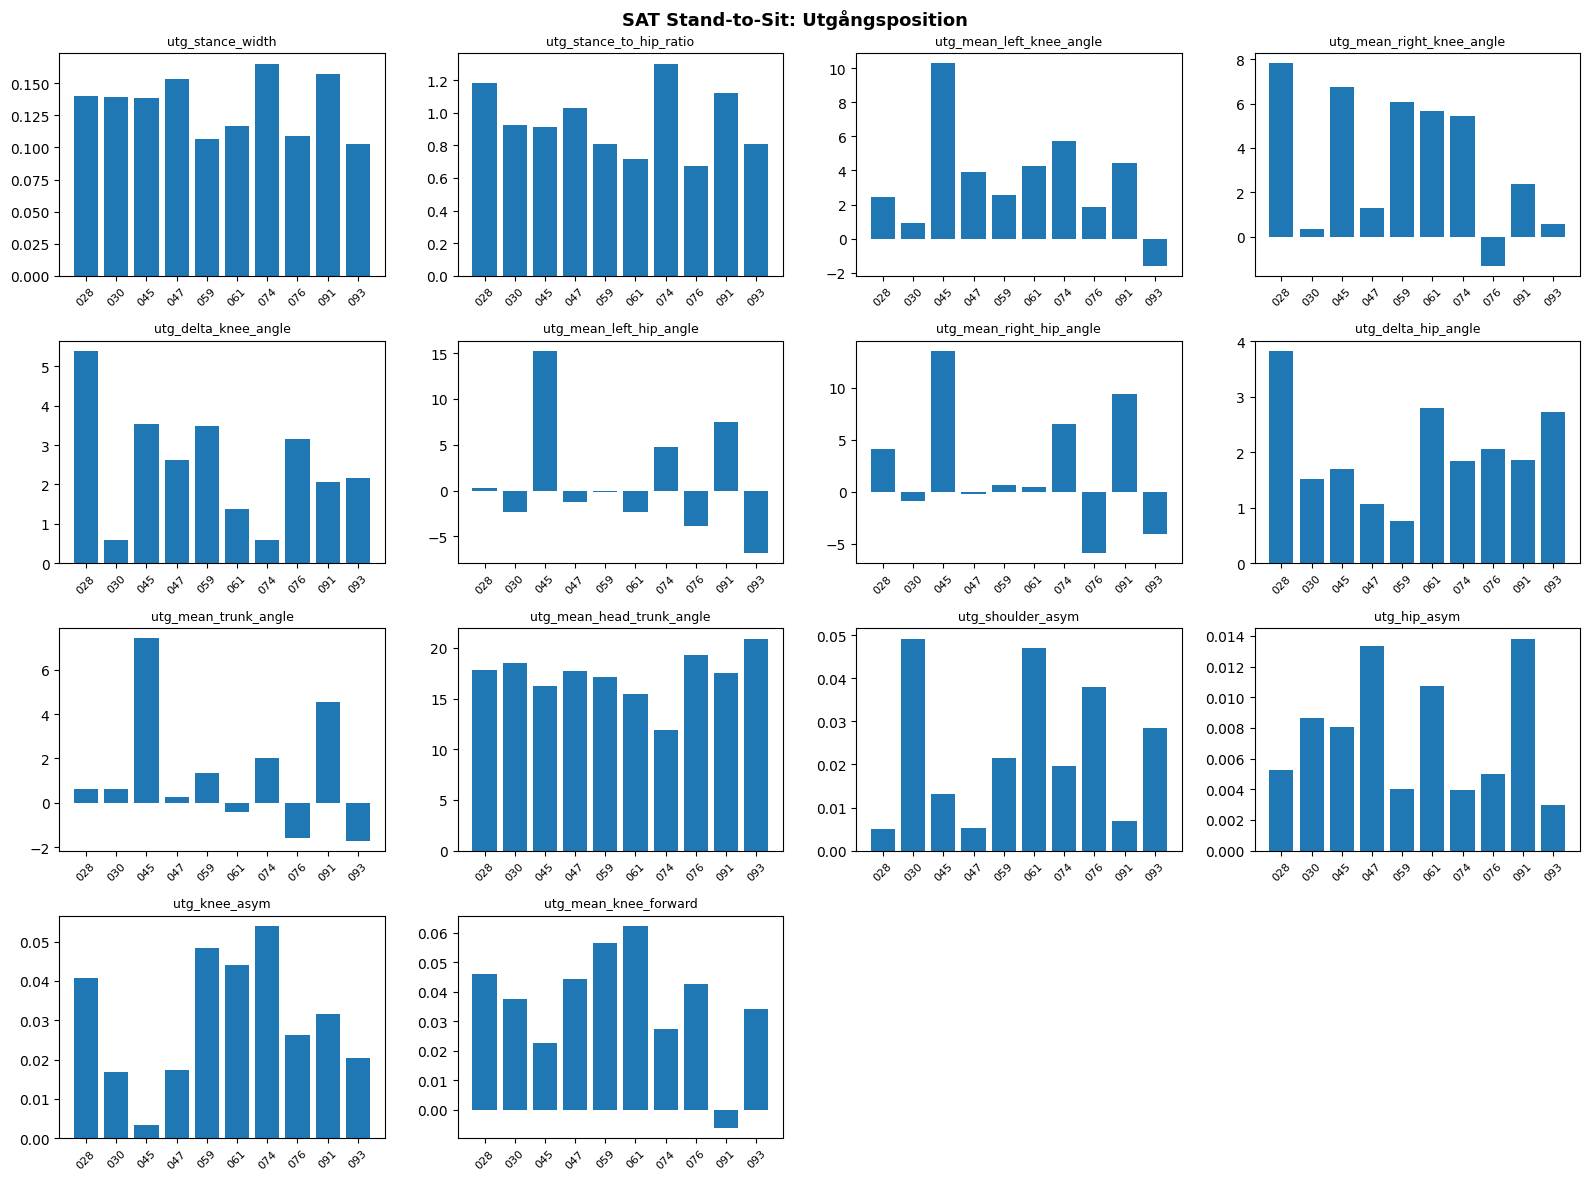

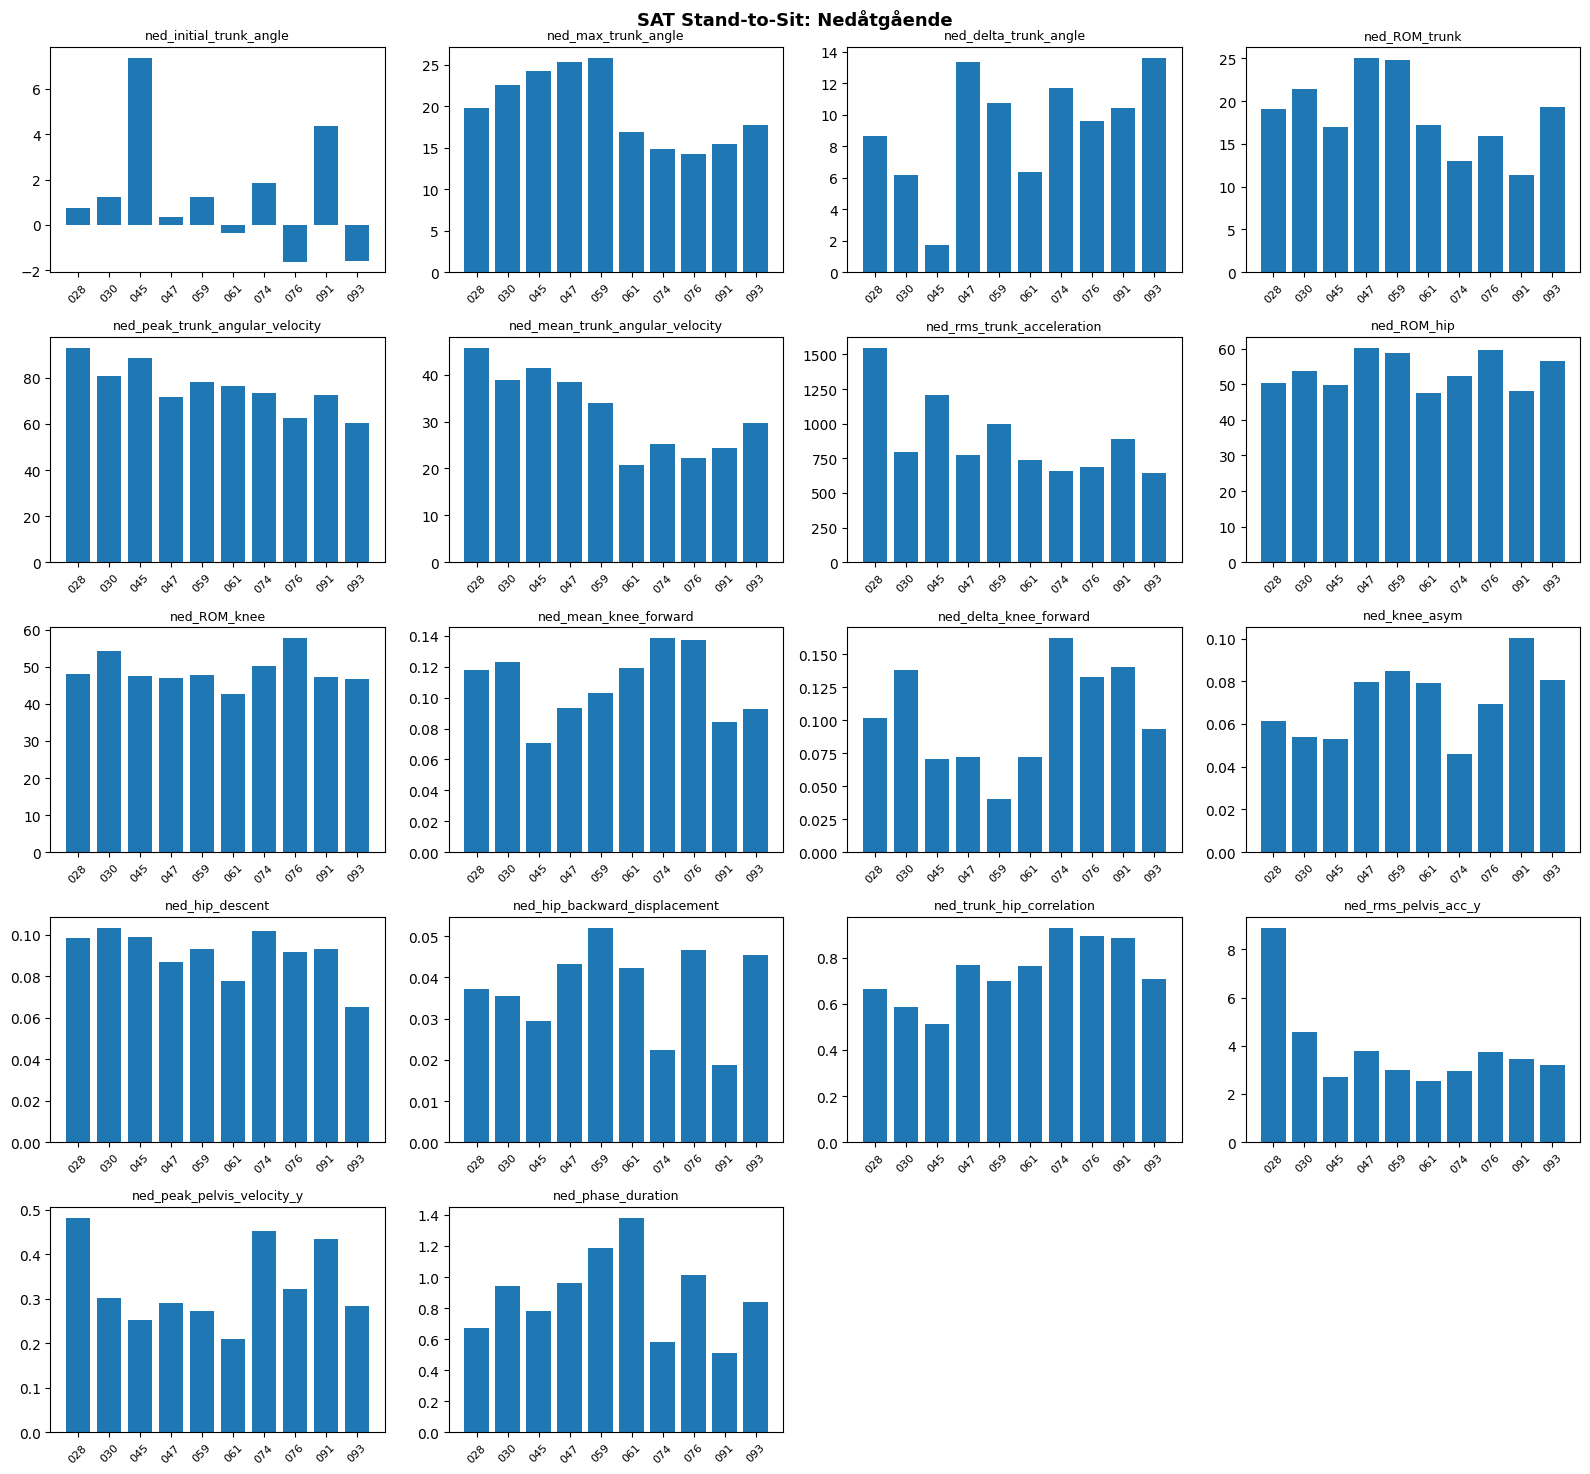

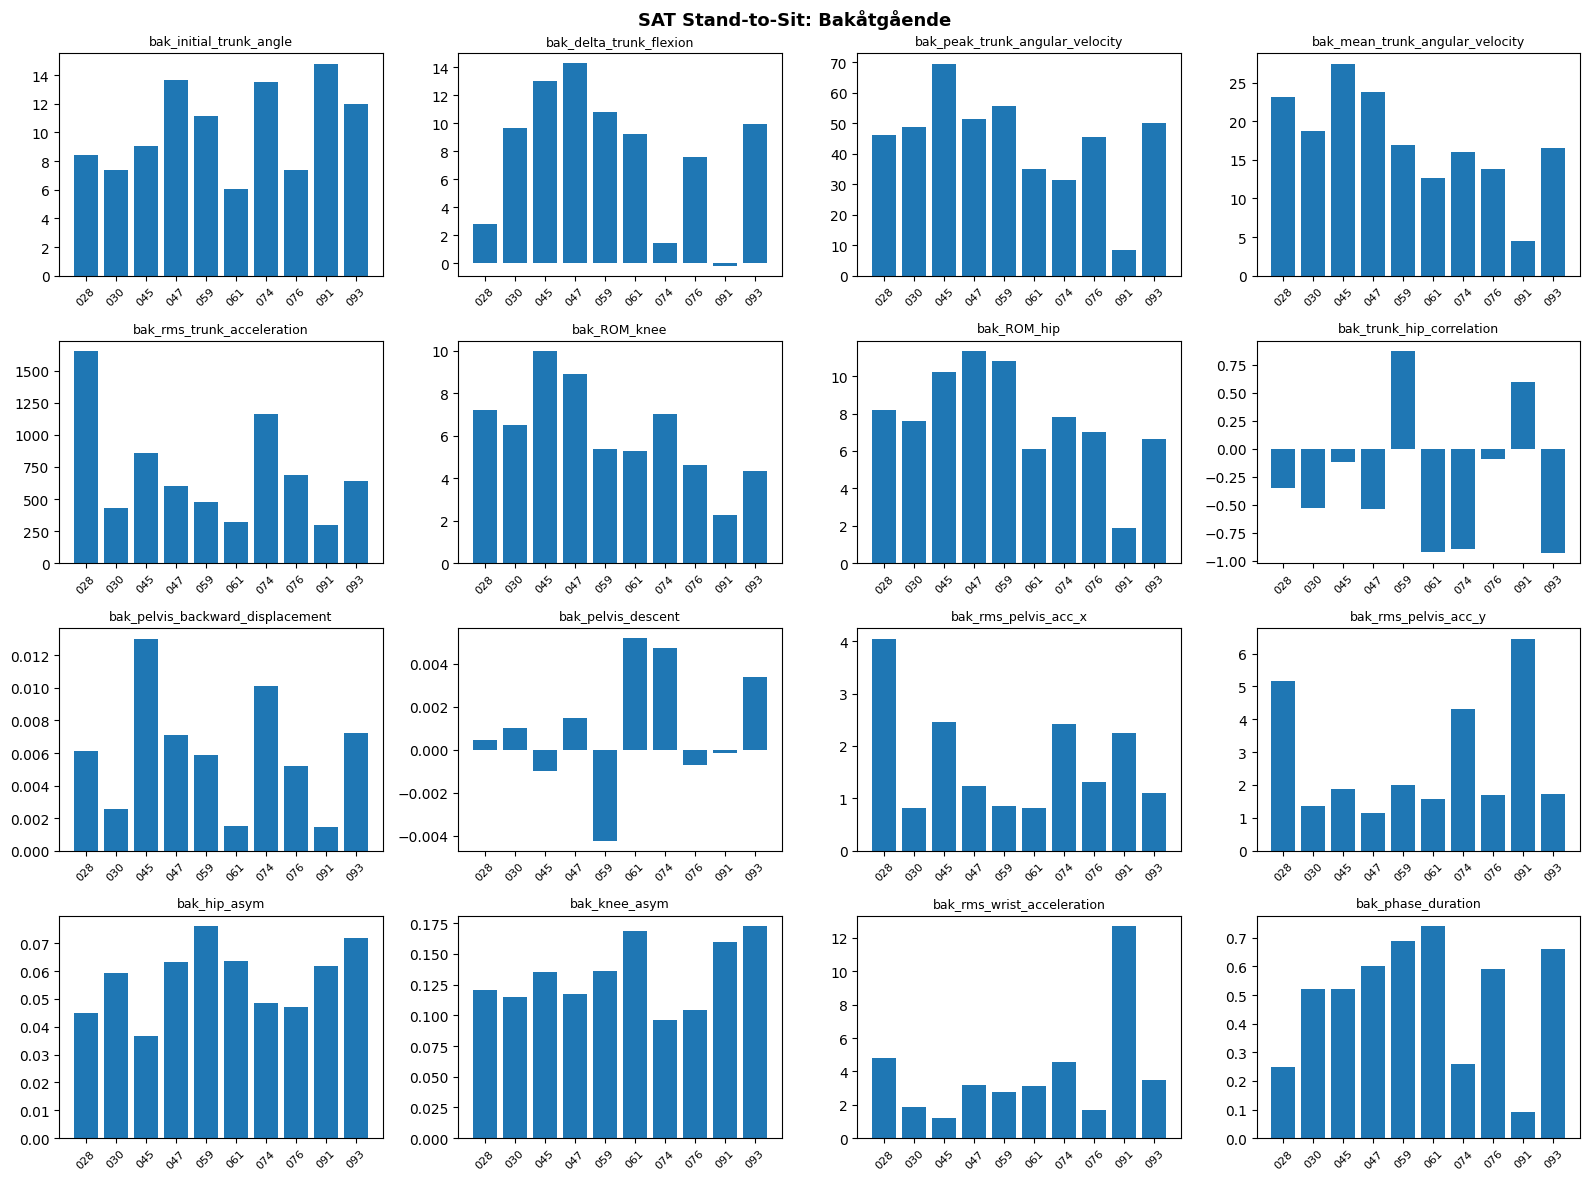

In [21]:
plot_phase(df_down_utgång, 'SAT Stand-to-Sit: Utgångsposition', ncols=4, filepath=DOWN_OUT_DIR / 'down_utgångsposition.png')
plot_phase(df_ned,         'SAT Stand-to-Sit: Nedåtgående',     ncols=4, filepath=DOWN_OUT_DIR / 'down_nedåtgående.png')
plot_phase(df_bak,         'SAT Stand-to-Sit: Bakåtgående',     ncols=4, filepath=DOWN_OUT_DIR / 'down_bakåtgående.png')

## MoLab Features

In [22]:
MOLAB_DOWN_DIR = Path('../data/processed/molab_cropped_down')

molab_corrected_down = {}
for vid in DOWN_TIME_DICT:
    cropped   = pd.read_csv(MOLAB_DOWN_DIR / f'0{vid}_molab.csv')
    corrected = cropped.copy()
    corrected[JOINT_ANGLE_COLS] = cropped[JOINT_ANGLE_COLS] + offsets[vid]
    molab_corrected_down[vid] = corrected

In [23]:
def molab_extract_down_utgångsposition(df, t0, t1):
    p = molab_phase(df, t0, t1)
    lk, rk = p['JointAngle/L_knee_X'], p['JointAngle/R_knee_X']
    return {
        'utg_mean_L_knee_flexion':  lk.mean(),
        'utg_mean_R_knee_flexion':  rk.mean(),
        'utg_delta_knee_asymmetry': abs(lk.mean() - rk.mean()),
        'utg_mean_L_hip_flexion':   p['JointAngle/L_hip_X'].mean(),
        'utg_mean_R_hip_flexion':   p['JointAngle/R_hip_X'].mean(),
        'utg_mean_pelvis_tilt':     p['JointAngle/pelvis_X'].mean(),
        'utg_mean_pelvis_lateral':  p['JointAngle/pelvis_Y'].abs().mean(),
        'utg_mean_L_ankle_flexion': p['JointAngle/L_ankle_X'].mean(),
        'utg_mean_R_ankle_flexion': p['JointAngle/R_ankle_X'].mean(),
    }

def molab_extract_down_rörelseutförande(df, t1, t2, t3):
    ned = molab_phase(df, t1, t2)
    bak = molab_phase(df, t2, t3)
    return {
        'ned_delta_pelvis_tilt':  ned['JointAngle/pelvis_X'].max() - ned['JointAngle/pelvis_X'].min(),
        'ned_peak_pelvis_gyro':   ned['SegmentGyro/pelvis_X'].abs().max(),
        'ned_mean_pelvis_gyro':   ned['SegmentGyro/pelvis_X'].abs().mean(),
        'ned_ROM_hip':            ((ned['JointAngle/L_hip_X'].max() - ned['JointAngle/L_hip_X'].min()) +
                                    (ned['JointAngle/R_hip_X'].max() - ned['JointAngle/R_hip_X'].min())) / 2,
        'ned_ROM_knee':           ((ned['JointAngle/L_knee_X'].max() - ned['JointAngle/L_knee_X'].min()) +
                                    (ned['JointAngle/R_knee_X'].max() - ned['JointAngle/R_knee_X'].min())) / 2,
        'ned_knee_angle_diff':    (ned['JointAngle/L_knee_X'] - ned['JointAngle/R_knee_X']).abs().mean(),
        'ned_rms_pelvis_acc':     rms(ned['SegmentAcc/pelvis_Y'].values),
        'ned_peak_shank_gyro':    max(ned['SegmentGyro/L_shank_X'].abs().max(),
                                       ned['SegmentGyro/R_shank_X'].abs().max()),
        'ned_pelvis_lateral':     ned['JointAngle/pelvis_Y'].abs().mean(),
        'ned_peak_thigh_gyro':    max(ned['SegmentGyro/L_thigh_X'].abs().max(),
                                       ned['SegmentGyro/R_thigh_X'].abs().max()),
        'bak_delta_pelvis_tilt':  bak['JointAngle/pelvis_X'].max() - bak['JointAngle/pelvis_X'].min(),
        'bak_mean_pelvis_gyro':   bak['SegmentGyro/pelvis_X'].abs().mean(),
        'bak_pelvis_lateral':     bak['JointAngle/pelvis_Y'].abs().mean(),
        'bak_rms_pelvis_acc':     rms(bak['SegmentAcc/pelvis_Y'].values),
        'bak_peak_pelvis_gyro':   bak['SegmentGyro/pelvis_X'].abs().max(),
        'bak_ROM_knee':           ((bak['JointAngle/L_knee_X'].max() - bak['JointAngle/L_knee_X'].min()) +
                                    (bak['JointAngle/R_knee_X'].max() - bak['JointAngle/R_knee_X'].min())) / 2,
        'bak_ROM_hip':            ((bak['JointAngle/L_hip_X'].max() - bak['JointAngle/L_hip_X'].min()) +
                                    (bak['JointAngle/R_hip_X'].max() - bak['JointAngle/R_hip_X'].min())) / 2,
    }

In [24]:
rows_utg, rows_ned, rows_bak = [], [], []

for vid, (t0, t1, t2, t3) in DOWN_TIME_DICT.items():
    df = molab_corrected_down[vid]
    rows_utg.append({'video': vid, **molab_extract_down_utgångsposition(df, t0, t1)})
    all_ru = molab_extract_down_rörelseutförande(df, t1, t2, t3)
    rows_ned.append({'video': vid, **{k: v for k, v in all_ru.items() if k.startswith('ned_')}})
    rows_bak.append({'video': vid, **{k: v for k, v in all_ru.items() if k.startswith('bak_')}})

df_down_molab_utg = pd.DataFrame(rows_utg).set_index('video')
df_down_molab_ned = pd.DataFrame(rows_ned).set_index('video')
df_down_molab_bak = pd.DataFrame(rows_bak).set_index('video')

df_down_molab_utg.to_csv(DOWN_OUT_DIR / 'down_molab_utgångsposition.csv')
df_down_molab_ned.to_csv(DOWN_OUT_DIR / 'down_molab_nedåtgående.csv')
df_down_molab_bak.to_csv(DOWN_OUT_DIR / 'down_molab_bakåtgående.csv')

print("=== Utgångsposition ===");   display(df_down_molab_utg.round(2))
print("=== Ned (Nedåtgående) ==="); display(df_down_molab_ned.round(4))
print("=== Bak (Bakåtgående) ==="); display(df_down_molab_bak.round(4))

=== Utgångsposition ===


,utg_mean_L_knee_flexion,utg_mean_R_knee_flexion,utg_delta_knee_asymmetry,utg_mean_L_hip_flexion,utg_mean_R_hip_flexion,utg_mean_pelvis_tilt,utg_mean_pelvis_lateral,utg_mean_L_ankle_flexion,utg_mean_R_ankle_flexion
video,,,,,,,,,
028,3.57,5.84,2.27,-2.07,2.78,7.86,1.74,65.46,62.94
030,-1.40,2.90,4.30,-5.23,2.86,13.21,2.16,68.60,65.65
045,14.14,10.41,3.73,27.63,30.94,28.43,1.48,73.30,64.64
047,-5.94,-6.58,0.64,-4.54,1.48,19.80,0.66,76.07,69.63
059,-0.94,-5.98,5.04,9.91,10.87,31.40,8.20,72.25,64.32
061,1.81,0.04,1.77,10.19,12.87,31.25,4.21,75.48,70.03
074,10.94,3.66,7.29,21.75,21.40,26.20,3.29,74.41,66.10
076,-5.15,-7.05,1.90,0.17,1.03,24.59,0.94,76.88,70.74
091,-1.20,-3.27,2.07,6.96,12.33,15.45,1.97,57.23,52.56


=== Ned (Nedåtgående) ===


,ned_delta_pelvis_tilt,ned_peak_pelvis_gyro,ned_mean_pelvis_gyro,ned_ROM_hip,ned_ROM_knee,ned_knee_angle_diff,ned_rms_pelvis_acc,ned_peak_shank_gyro,ned_pelvis_lateral,ned_peak_thigh_gyro
video,,,,,,,,,,
028,26.281,116.043,70.0996,91.6405,95.1020,2.1902,0.8077,62.513,2.7478,208.973
030,30.553,99.878,51.0267,100.4580,99.2350,6.1053,0.4090,52.528,3.1307,143.262
045,32.085,125.708,68.4915,82.7730,72.4765,2.0524,0.9110,48.380,0.8680,113.033
047,45.217,108.712,70.2021,110.3370,88.4585,2.8550,0.4780,43.476,1.7763,142.506
059,26.212,79.373,39.5243,83.2935,91.8645,7.9103,0.8052,24.107,6.1276,121.115
061,19.385,62.564,26.1241,72.6760,87.7675,7.0752,0.3744,38.507,2.7431,93.232
074,29.158,258.384,63.8435,94.3850,89.8740,8.0900,0.8400,97.647,2.6948,177.313
076,27.069,108.315,44.9727,104.2485,104.2040,5.3986,0.2807,53.560,1.4755,120.934
091,30.969,122.634,64.5256,95.6190,88.1190,1.8198,1.0861,111.899,1.0155,228.109


=== Bak (Bakåtgående) ===


,bak_delta_pelvis_tilt,bak_mean_pelvis_gyro,bak_pelvis_lateral,bak_rms_pelvis_acc,bak_peak_pelvis_gyro,bak_ROM_knee,bak_ROM_hip
video,,,,,,,
028,13.930,53.7106,4.1452,0.4051,78.379,1.6650,10.2110
030,17.671,31.2309,4.7833,0.0890,84.195,2.3355,12.7970
045,47.214,88.5524,0.7263,0.7265,483.498,2.3720,41.5185
047,27.058,42.9984,0.2722,0.1126,91.558,1.8495,24.2135
059,11.999,18.2866,4.4873,0.4541,53.218,0.6995,10.3310
061,21.196,28.3958,2.8263,0.1475,101.006,2.7935,15.5275
074,6.265,30.1440,0.3483,0.7222,67.899,4.6775,4.5130
076,20.229,32.1479,0.7683,0.1339,50.549,2.1025,16.8295
091,1.445,33.4481,2.0350,0.9434,111.864,0.5040,2.1680


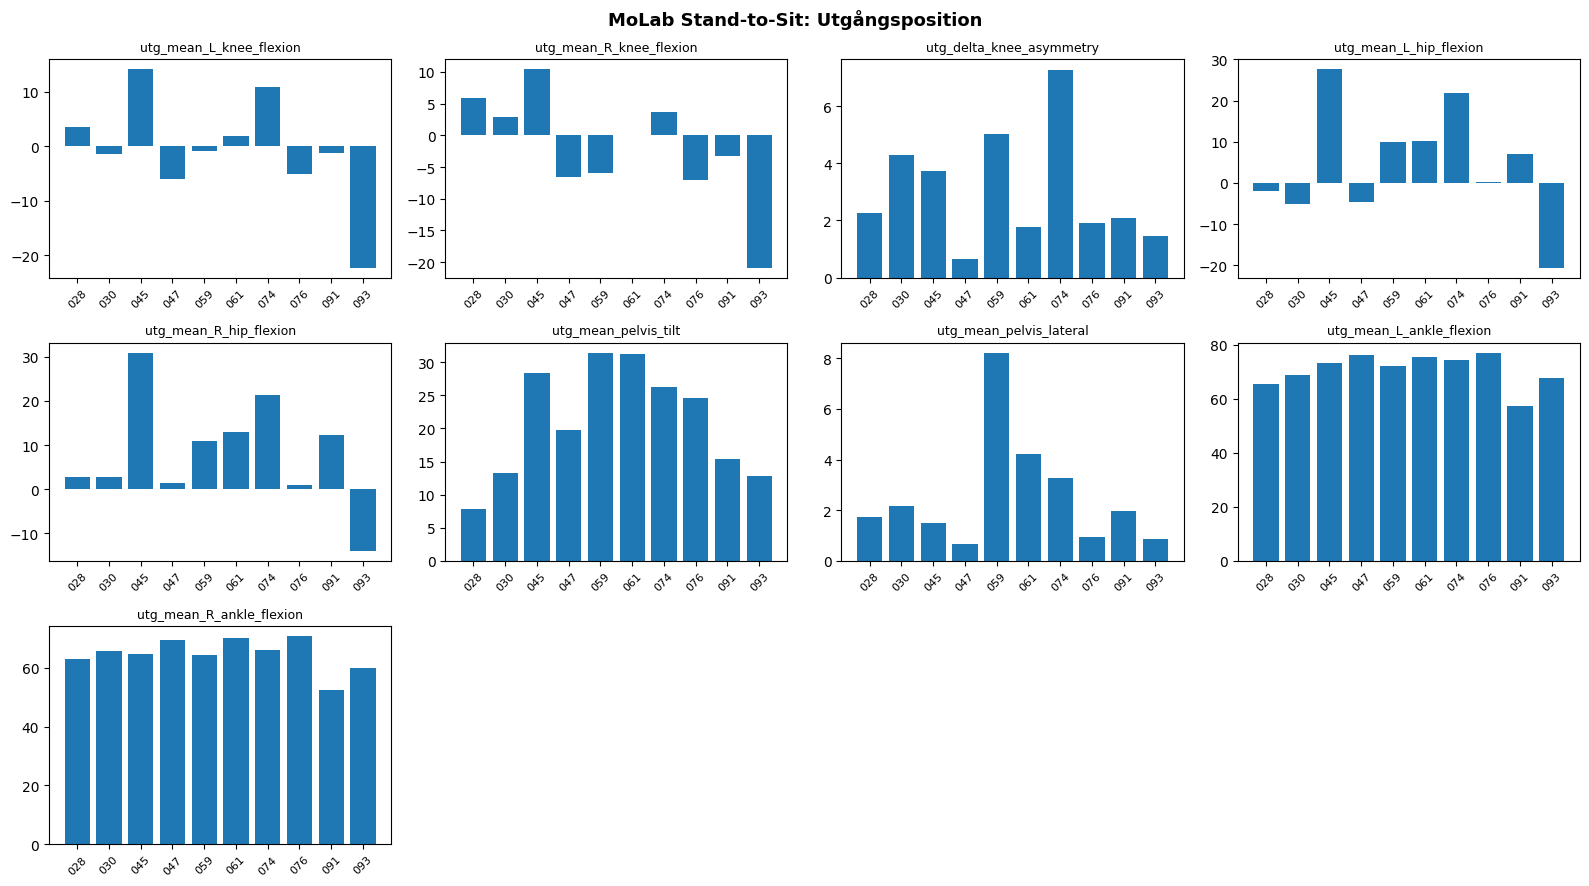

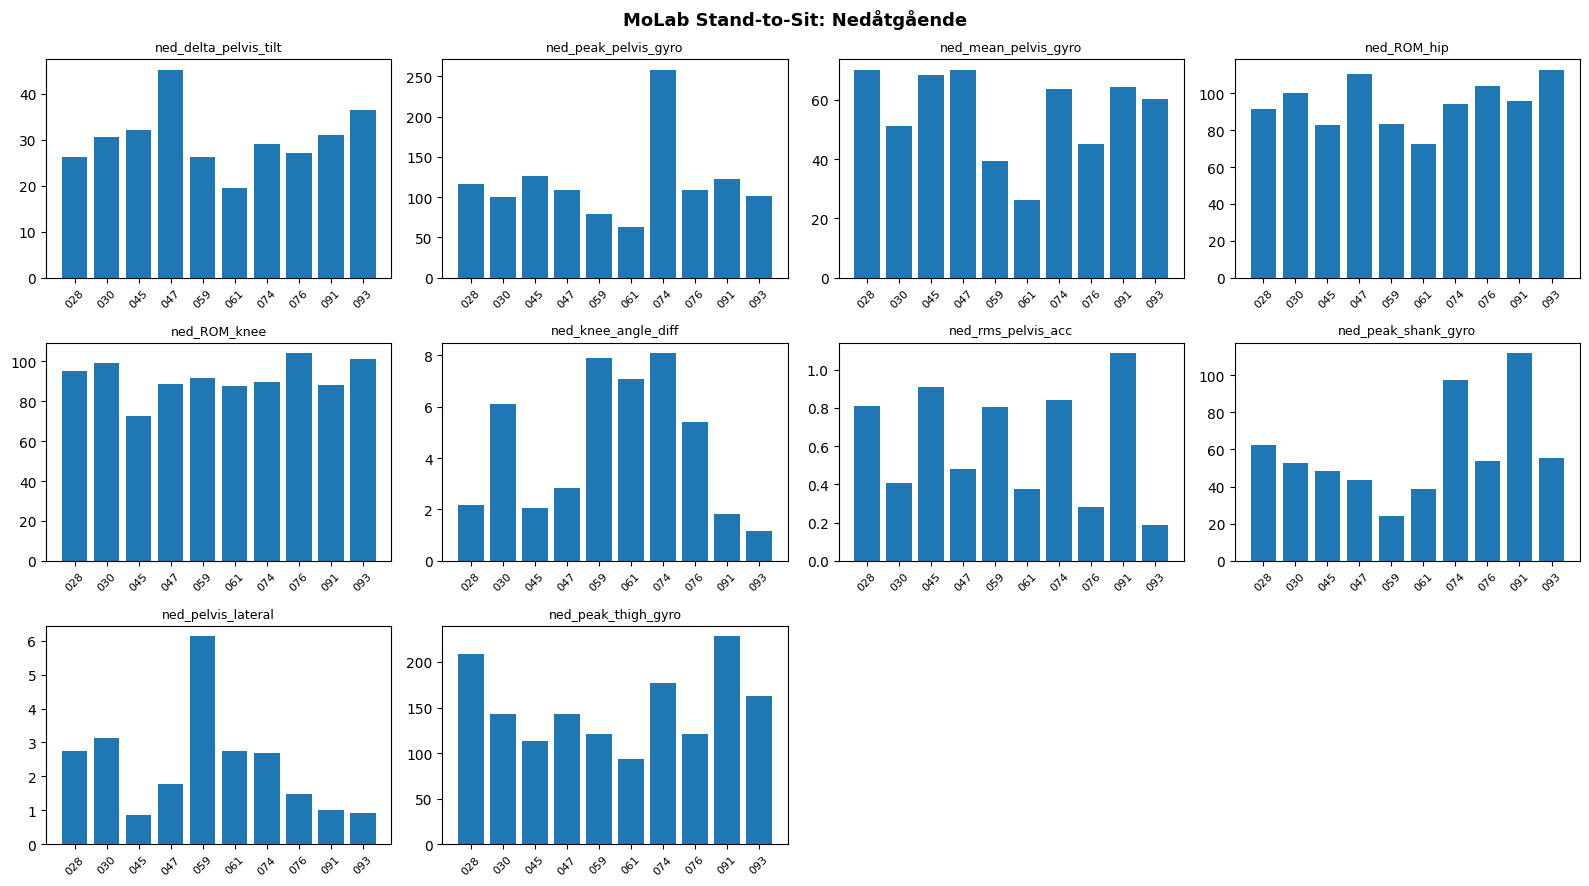

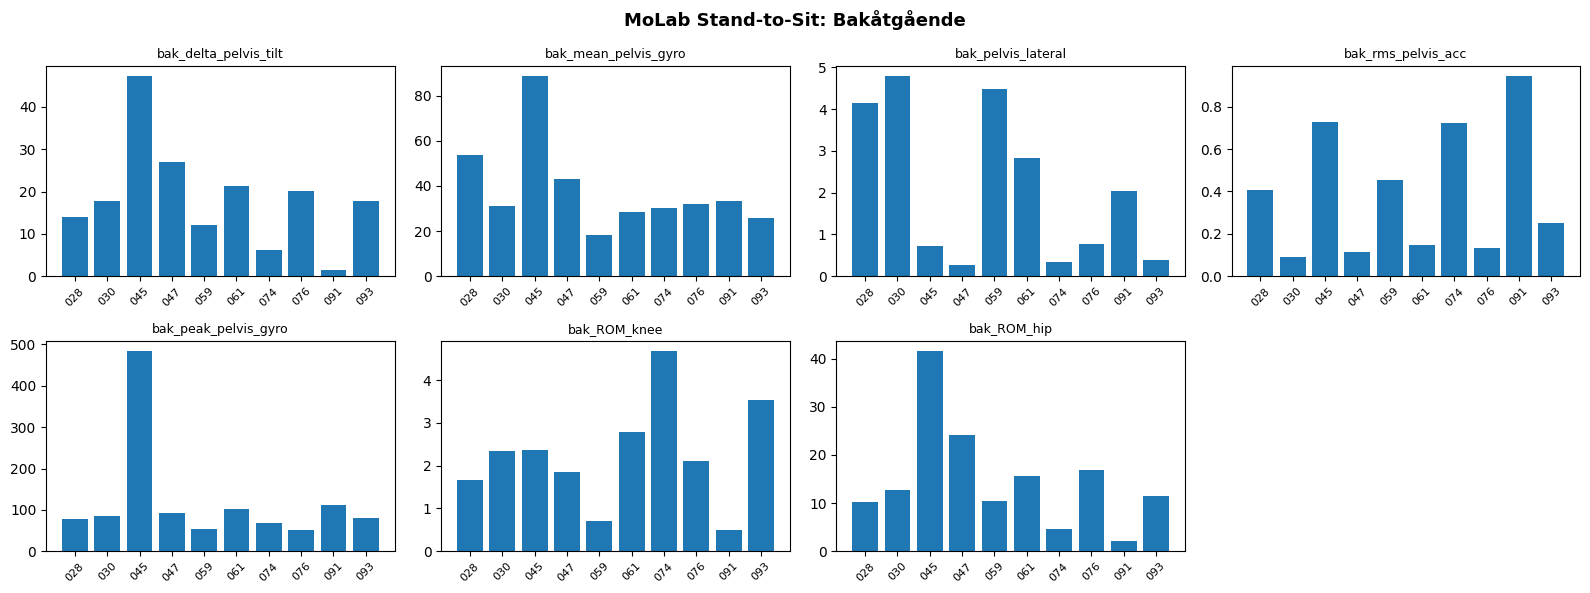

In [25]:
plot_phase(df_down_molab_utg, 'MoLab Stand-to-Sit: Utgångsposition', ncols=4, filepath=DOWN_OUT_DIR / 'down_molab_utgångsposition.png')
plot_phase(df_down_molab_ned, 'MoLab Stand-to-Sit: Nedåtgående',     ncols=4, filepath=DOWN_OUT_DIR / 'down_molab_nedåtgående.png')
plot_phase(df_down_molab_bak, 'MoLab Stand-to-Sit: Bakåtgående',     ncols=4, filepath=DOWN_OUT_DIR / 'down_molab_bakåtgående.png')